# Yelp Spark — Етап машинного навчання

Регресійні та класифікаційні моделі в PySpark ML на рівні **користувача** Yelp (1 987 897 записів).

* **Регресія:** скільки фанів має користувач — ціль `log(1 + fans)`.
  Моделі: `LinearRegression`, `FMRegressor` (factorization machine), `GBTRegressor` (градієнтний бустинг).
* **Класифікація:** чи був користувач у Yelp Elite — ціль `is_elite` (4,6% користувачів).
  Моделі: `LogisticRegression`, `RandomForestClassifier`, `MultilayerPerceptronClassifier` (нейронна мережа).

| Вимога | Де виконано в зошиті |
| --- | --- |
| 1. Регресійна та класифікаційна модель у PySpark | розд. 3 (регресія), розд. 4 (класифікація) |
| 2. Попередня обробка даних | розд. 2 |
| 3. Мінімум 3 моделі для кожної задачі | по 3 моделі різних типів |
| 4. Навчання та аналіз процесу навчання | розд. 3.1–3.2, 4.1–4.2 |
| 5. Метрики: RMSE, R²; Accuracy, Precision, Recall, F1 | розд. 3.3, 4.3 |
| 6. Порівняння алгоритмів | розд. 3.3, 4.3, 5 |

Повний звіт з висновками: [`src/reports/ml/README.md`](../reports/ml/README.md).
Той самий конвеєр без зошита: `uv run -m src.ml.run`.

## 1. Налаштування

In [1]:
import json
import os
import sys
import time
from pathlib import Path

# Make sure project root is on sys.path when running the notebook directly
project_root = Path("__file__").resolve().parent.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Use every core for training (src.spark.session reads this variable).
os.environ.setdefault("SPARK_MAX_CORES", str(os.cpu_count()))

import pandas as pd
from IPython.display import Image, display
from pyspark.sql import functions as F

from src.constants import ML_REPORT_DIR, ML_RESULTS_DIR
from src.ml import features as ft
from src.ml import plots, report
from src.ml.models import FM, GBT, LINEAR, LOGISTIC, RANDOM_FOREST
from src.ml.training import (
    configure_spark_for_training,
    release,
    run_classification,
    run_regression,
)
from src.spark.load_data import load_dataset
from src.spark.session import create_spark_session

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

FIG = ML_REPORT_DIR / "figures"
TABLES = ML_REPORT_DIR / "tables"
started = time.perf_counter()

spark = create_spark_session("yelp-ml-notebook")
spark.sparkContext.setLogLevel("ERROR")
configure_spark_for_training(spark)
print("Spark", spark.version, "| cores:", spark.sparkContext.defaultParallelism)


def show(path):
    display(Image(filename=str(path)))

Picked up JAVA_TOOL_OPTIONS: -XX:+IgnoreUnrecognizedVMOptions -Xmx8g -XX:+UseG1GC -XX:-UseContainerSupport
Picked up JAVA_TOOL_OPTIONS: -XX:+IgnoreUnrecognizedVMOptions -Xmx8g -XX:+UseG1GC -XX:-UseContainerSupport


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/10/03 19:27:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1 | cores: 8


## 2. Попередня обробка даних

**Одиниця аналізу — користувач.** Таблиця ознак будується з `user` (3,4 ГБ JSON; більшість обсягу — списки друзів),
зберігається у Parquet (`artifacts/processed/ml/user_features`). Перетворення без навчання на даних (`src/ml/features.py`):

* `friends` (`"None"` або список id через кому) → кількість друзів;
* `yelping_since` → стаж на Yelp у роках відносно дати знімка (остання реєстрація, 2022-01-19);
* `elite` (`"2017,2018"`; у сирих даних 2020 рік записано як `"20,20"`) → `is_elite` і кількість елітних років;
* голоси `useful/funny/cool` та 10 видів компліментів → `log1p` (важкі хвости) + сума компліментів
  (`compliment_funny` у сирих даних дублює `compliment_cool` для кожного користувача, тому не використовується);
* «якість» замість обсягу: голоси та компліменти **на один відгук** (ділення через `try_divide`, бо Spark 4 працює в ANSI-режимі).

Перетворення, які **навчаються** (Spark ML `Pipeline`, `fit` лише на train): `Imputer(median)` → `VectorAssembler` → `StandardScaler`
(нульове середнє, одинична дисперсія — потрібно для нейронної мережі та factorization machine, і робить коефіцієнти
лінійних моделей порівнянними).

**Захист від витоку цілі:** у регресії немає `fans`, у класифікації немає нічого, похідного від колонки `elite`.
Ціль іншої задачі є звичайною ознакою (`is_elite` для фанів, `fans` для еліти).

In [2]:
features = ft.load_or_build_features(spark).cache()
print(f"Feature table: {features.count():,} users x {len(features.columns)} columns")
summary_stats = features.drop("user_id").summary("mean", "min", "50%", "max").toPandas()
display(summary_stats.set_index("summary").T.astype(float).round(3))

Feature table: 1,987,897 users x 28 columns


summary,mean,min,50%,max
log_fans,0.270,0.0,0.000,9.433
is_elite,0.046,0.0,0.000,1.000
fans,1.466,0.0,0.000,12497.000
review_count,23.394,0.0,5.000,17473.000
n_elite_years,0.171,0.0,0.000,16.000
log_review_count,2.122,0.0,1.792,9.768
years_on_yelp,7.286,0.0,7.272,17.270
log_friends,1.898,0.0,1.099,9.616
average_stars,3.630,1.0,3.880,5.000
log_useful,1.670,0.0,1.386,12.237


In [3]:
# Before/after for three users whose raw `elite` contains the "20,20" bug
raw = load_dataset(spark, "user")
ids = [r.user_id for r in raw.filter(F.col("elite").contains("20,20")).select("user_id").limit(3).collect()]
raw.filter(F.col("user_id").isin(ids)).select(
    "user_id",
    "yelping_since",
    F.substring("friends", 1, 40).alias("friends (start)"),
    "elite",
    "review_count",
    "useful",
    "fans",
).show(truncate=False)
features.filter(F.col("user_id").isin(ids)).select(
    "user_id", "years_on_yelp", "log_friends", "is_elite", "n_elite_years",
    "log_review_count", "useful_per_review", "log_fans",
).show()

+----------------------+-------------------+----------------------------------------+-----------------------------------------------------------------+------------+------+----+
|user_id               |yelping_since      |friends (start)                         |elite                                                            |review_count|useful|fans|
+----------------------+-------------------+----------------------------------------+-----------------------------------------------------------------+------------+------+----+
|j14WgRoU_-2ZE1aw1dXrJg|2009-01-25 04:35:42|ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5|2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,20,20,2021|4333        |43091 |3138|
|QF1Kuhs8iwLWANNZxebTow|2009-04-27 20:25:54|dLts9bY66tXEFqYG03YFgw, SYDGMC7d5NnMiT1l|2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,20,20,2021     |607         |4573  |131 |
|4ZaqBJqt7laPPs8xfWvr6A|2008-08-16 22:43:21|v56_o8iCNYGB2JFVIhOwQA, yFLNHDlCriteboCV|2010,2011,2012,2013,2014,2015,

+--------------------+------------------+------------------+--------+-------------+-----------------+------------------+-----------------+
|             user_id|     years_on_yelp|       log_friends|is_elite|n_elite_years| log_review_count| useful_per_review|         log_fans|
+--------------------+------------------+------------------+--------+-------------+-----------------+------------------+-----------------+
|QF1Kuhs8iwLWANNZx...|12.731006160164272|6.1903154058531475|     1.0|         12.0|6.410174881966167| 7.533772652388797|4.882801922586371|
|j14WgRoU_-2ZE1aw1...|12.982888432580424| 8.443977129084978|     1.0|         13.0|8.374246182096304| 9.944841910916224|8.051659556841953|
|4ZaqBJqt7laPPs8xf...|13.426420260095824|  6.20050917404269|     1.0|         12.0|6.687108607866515|2.4269662921348316|4.330733340286331|
+--------------------+------------------+------------------+--------+-------------+-----------------+------------------+-----------------+



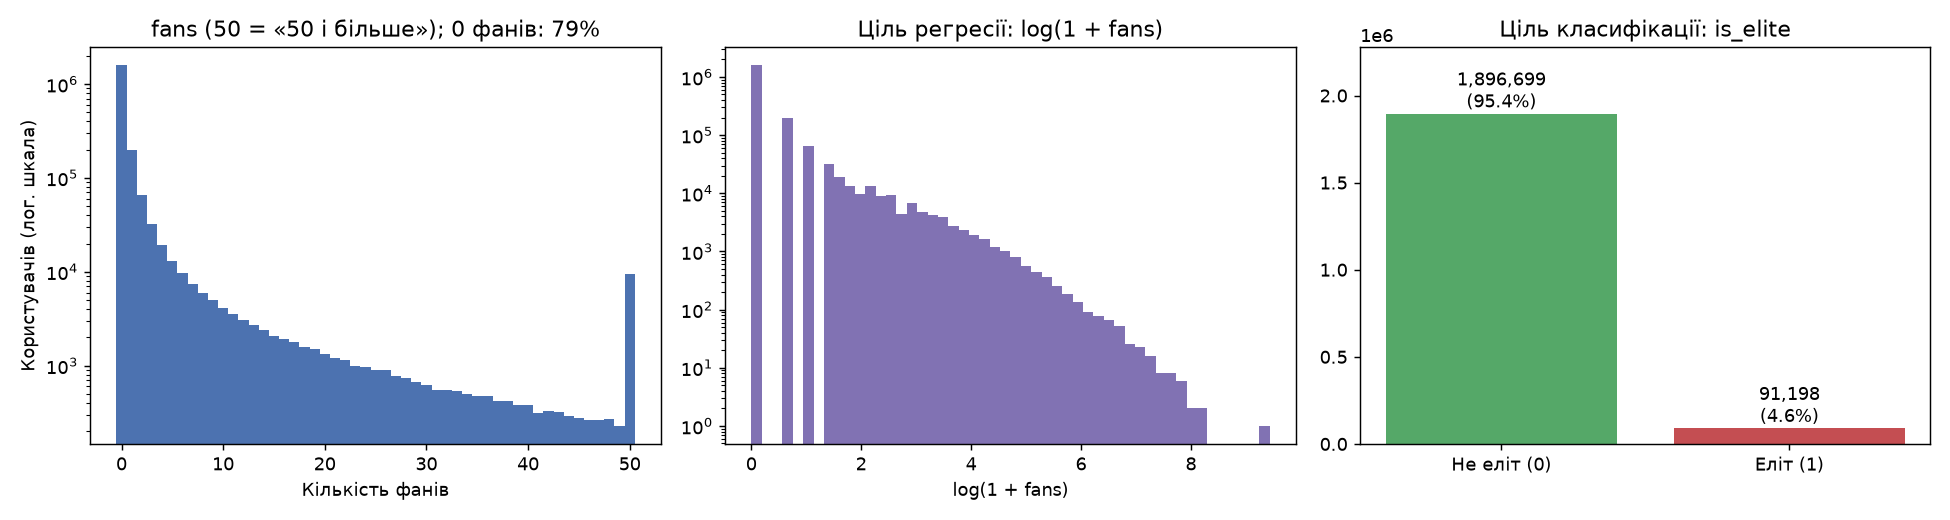

In [4]:
fan_counts = features.groupBy("fans", "is_elite").count().toPandas()
show(plots.target_distributions(fan_counts, FIG / "targets.png"))

**Розбиття.** Детерміноване за хешем `user_id` (`xxhash64 mod 100`): 70% train / 15% validation / 15% test,
однакове для обох задач і всіх запусків. Гіперпараметри обираються на validation, тест оцінюється **один раз**
моделлю, навченою лише на train.

## 3. Регресія: кількість фанів, `log(1 + fans)`

Моделі різних типів: лінійна (`LinearRegression`, L-BFGS), лінійна з попарними взаємодіями ознак
(`FMRegressor`, AdamW) і ансамбль дерев (`GBTRegressor`, бустинг). Базові рівні: середнє train і «0 фанів» (медіана).
Критерій вибору — RMSE на validation. Метрики — на шкалі `log(1 + fans)`; MAE/RMSE у фанах — для інтерпретації.

In [5]:
regression = run_regression(features)

[19:27:31] Task regression: preparing data


[19:27:39] Task regression: 24 features, train/val/test = 1391658/298044/298195


[19:27:39] Task regression: tuning LinearRegression (3 settings)


[19:27:47]   LinearRegression {'regParam': 0.001} fit 5.4s train rmse=0.3150 val rmse=0.3170


[19:27:52]   LinearRegression {'regParam': 0.01} fit 3.6s train rmse=0.3151 val rmse=0.3171


...

[19:40:00]   learning curve 1.4% (19732 rows) done


[19:40:30]   learning curve 4.3% (59639 rows) done


[19:41:04]   learning curve 10.0% (138902 rows) done


[19:41:51]   learning curve 24.3% (337961 rows) done


[19:42:45]   learning curve 50.0% (696313 rows) done


In [6]:
print("Fitted preprocessing PipelineModel stages:")
for i, stage in enumerate(regression.data.preprocessing.stages, 1):
    print(f"  {i}. {stage}")
print("Features:", regression.data.feature_names)
reg_tables = report.write_task(regression, TABLES)
display(reg_tables["splits"])

Fitted preprocessing PipelineModel stages:
  1. ImputerModel: uid=Imputer_59f4fceea7cf, strategy=median, missingValue=NaN, numInputCols=24, numOutputCols=24
  2. VectorAssembler_19f30a0591a8
  3. StandardScalerModel: uid=StandardScaler_2b139a4de77a, numFeatures=24, withMean=true, withStd=true
Features: ['log_review_count', 'years_on_yelp', 'log_friends', 'average_stars', 'log_useful', 'log_funny', 'log_cool', 'useful_per_review', 'funny_per_review', 'cool_per_review', 'log_compliment_hot', 'log_compliment_more', 'log_compliment_profile', 'log_compliment_cute', 'log_compliment_list', 'log_compliment_note', 'log_compliment_plain', 'log_compliment_cool', 'log_compliment_writer', 'log_compliment_photos', 'log_compliments_total', 'compliments_per_review', 'is_elite', 'n_elite_years']


,split,rows,mean_log_fans
0,train,1391658,0.270049
1,validation,298044,0.272762
2,test,298195,0.270234


### 3.1 Підбір гіперпараметрів (усі спроби: train / validation, час навчання)

In [7]:
display(reg_tables["tuning"])

,model,params,fit_seconds,search_seconds,train_rmse,val_rmse,train_r2,val_r2
0,LinearRegression,"{""regParam"": 0.001}",5.40,5.40,0.315033,0.317019,0.778184,0.779394
1,LinearRegression,"{""regParam"": 0.01}",3.58,3.58,0.315123,0.317101,0.778057,0.779280
2,LinearRegression,"{""regParam"": 0.1}",2.97,2.97,0.316500,0.318506,0.776113,0.777320
3,FMRegressor,"{""stepSize"": 0.001}",171.08,171.08,0.328720,0.331264,0.758491,0.759122
4,FMRegressor,"{""stepSize"": 0.01}",166.90,166.90,0.311354,0.313674,0.783333,0.784025
5,FMRegressor,"{""stepSize"": 0.1}",186.88,186.88,3.632918,3.742655,-28.498027,-29.747263
6,GBTRegressor,"{""maxDepth"": 3, ""maxIter"": 100}",54.98,54.98,0.299296,0.301060,0.799791,0.801046
7,GBTRegressor,"{""maxDepth"": 5, ""maxIter"": 100}",73.53,73.53,0.295348,0.299412,0.805038,0.803219


### 3.2 Аналіз процесу навчання

* збіжність L-BFGS лінійної регресії та вплив регуляризації;
* factorization machine: вплив кроку навчання AdamW (замалий — повільно, завеликий — розбіжність);
* GBT: RMSE на train і validation після кожної ітерації бустингу;
* крива навчання найкращої моделі та час навчання.

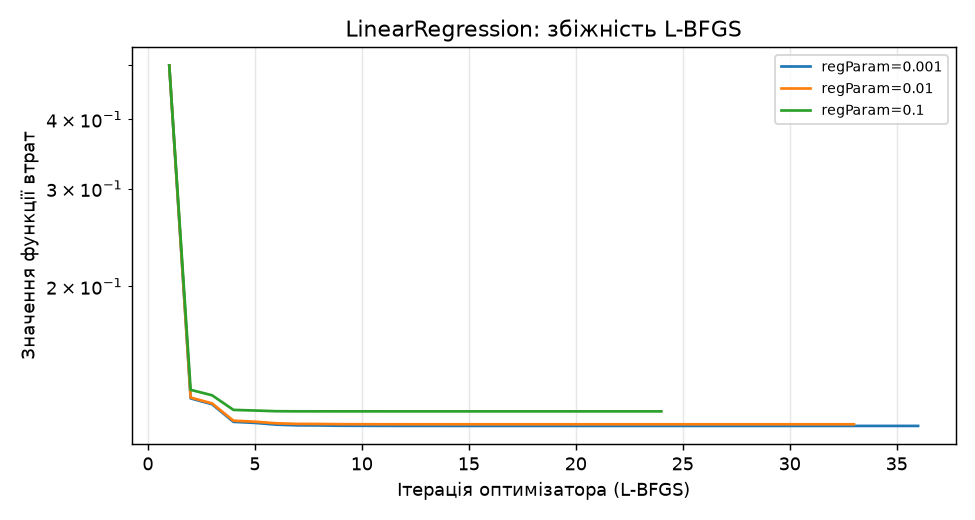

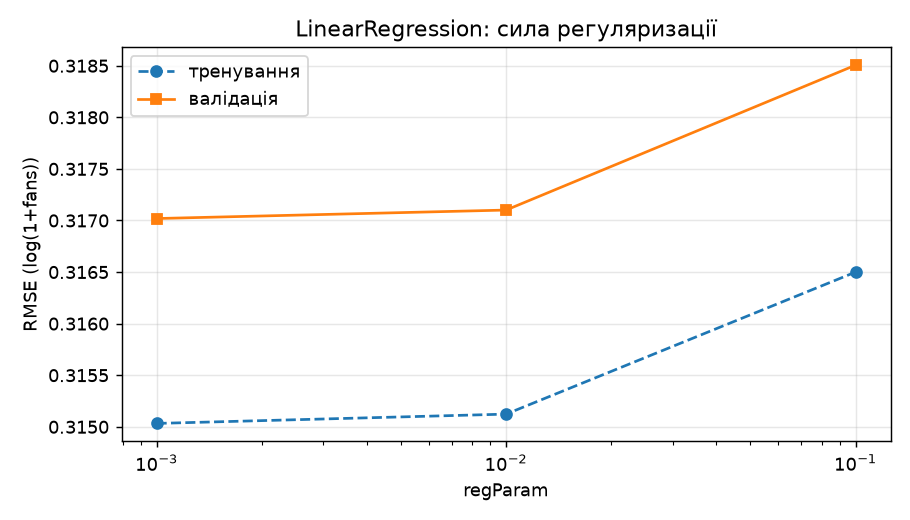

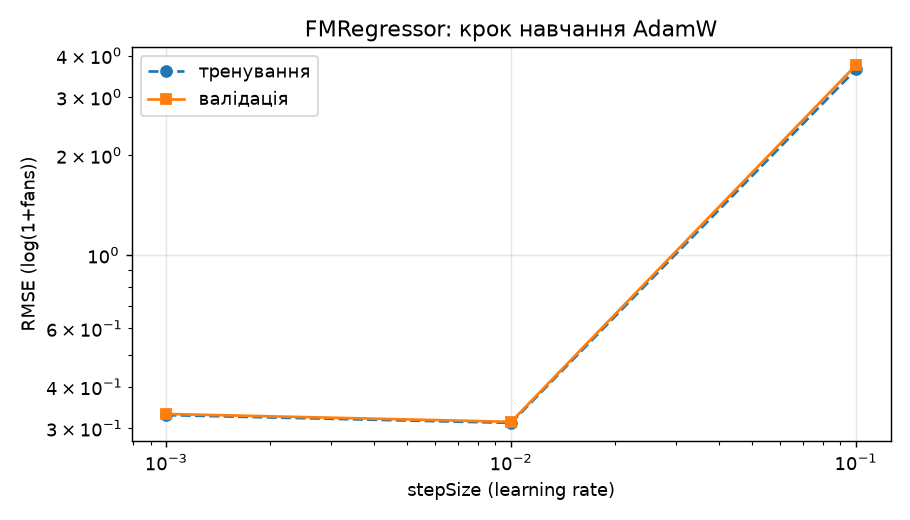

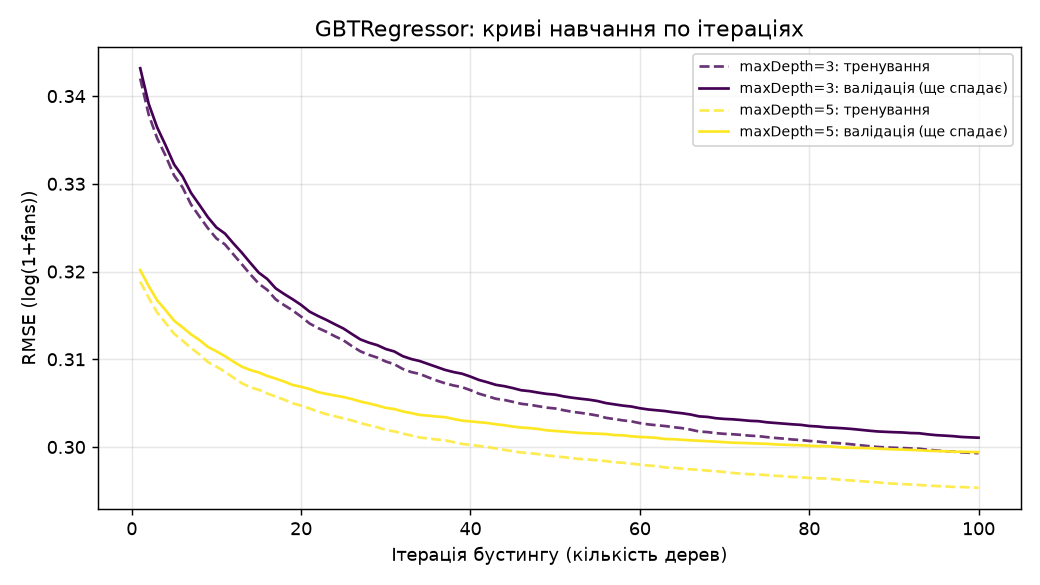

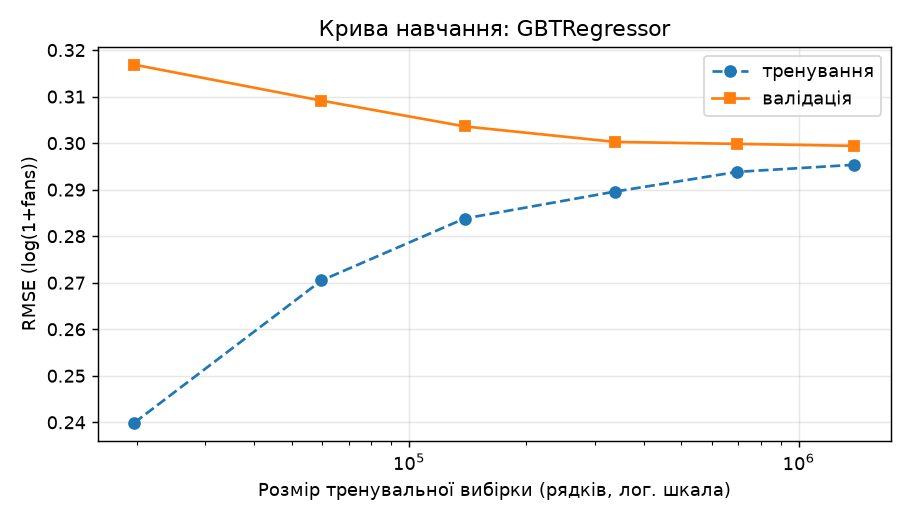

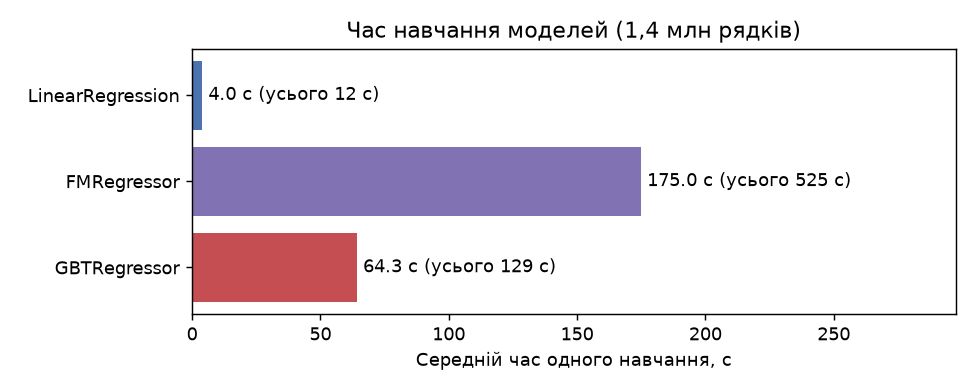

,train_fraction,train_rows,fit_seconds,train_rmse,train_r2,train_mae,train_mae_fans,train_rmse_fans,val_rmse,val_r2,val_mae,val_mae_fans,val_rmse_fans
0,0.014286,19732,23.93,0.239914,0.871879,0.137380,0.401655,1.834532,0.316855,0.779622,0.173840,0.918670,26.063123
1,0.042857,59639,28.44,0.270479,0.839194,0.153986,0.567785,5.418414,0.309132,0.790234,0.170755,0.912943,26.139541
2,0.100000,138902,32.26,0.283794,0.821060,0.160932,0.603774,5.639968,0.303601,0.797674,0.169058,0.857477,25.755603
3,0.242857,337961,45.23,0.289586,0.812833,0.163248,0.665147,7.030248,0.300263,0.802098,0.167522,0.835634,25.550845
4,0.500000,696313,51.50,0.293824,0.807465,0.164848,0.698936,8.654158,0.299840,0.802656,0.167168,0.824620,25.465686
5,1.000000,1391658,73.53,0.295348,0.805038,0.165488,0.710467,9.225732,0.299412,0.803219,0.167150,0.829162,25.331086


In [8]:
for path in [
    plots.objective_history(regression, LINEAR, FIG / "reg_linear_convergence.png",
                            "LinearRegression: збіжність L-BFGS"),
    plots.param_curve(regression, LINEAR, "regParam", "rmse", FIG / "reg_linear_regularization.png",
                      "LinearRegression: сила регуляризації", "regParam", log_x=True),
    plots.param_curve(regression, FM, "stepSize", "rmse", FIG / "reg_fm_learning_rate.png",
                      "FMRegressor: крок навчання AdamW", "stepSize (learning rate)", log_x=True, log_y=True),
    plots.gbt_iterations(regression, FIG / "reg_gbt_iterations.png"),
    plots.learning_curve(regression, "rmse", FIG / "reg_learning_curve.png"),
    plots.fit_times(regression, FIG / "reg_fit_times.png"),
]:
    show(path)
display(reg_tables["learning_curve"])

### 3.3 Якість моделей: RMSE, R² (тест, 95% bootstrap-інтервали) та порівняння

,model,rmse,r2,mae,mae_fans,rmse_fans,rmse_95ci,r2_95ci,fit_seconds,best_params
0,Baseline: train mean,0.669636,-7.609266e-08,0.429034,1.623125,14.696814,NaN,NaN,NaN,NaN
1,Baseline: 0 fans (median),0.722107,-1.628551e-01,0.270234,1.440816,14.723913,NaN,NaN,NaN,NaN
2,LinearRegression,0.314182,7.798663e-01,0.184354,0.835609,9.210516,[0.312; 0.316],[0.777; 0.783],5.4,"{""regParam"": 0.001}"
3,FMRegressor,0.310064,7.856003e-01,0.179786,0.838064,21.845741,[0.308; 0.312],[0.782; 0.790],166.9,"{""stepSize"": 0.01}"
4,GBTRegressor,0.297415,8.027354e-01,0.166662,0.737894,9.537245,[0.296; 0.299],[0.800; 0.806],73.5,"{""maxDepth"": 5, ""maxIter"": 100}"


,model,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,LinearRegression,0.315033,0.317019,0.314182,0.778184,0.779394,0.779866
1,FMRegressor,0.311354,0.313674,0.310064,0.783333,0.784025,0.785600
2,GBTRegressor,0.295348,0.299412,0.297415,0.805038,0.803219,0.802735


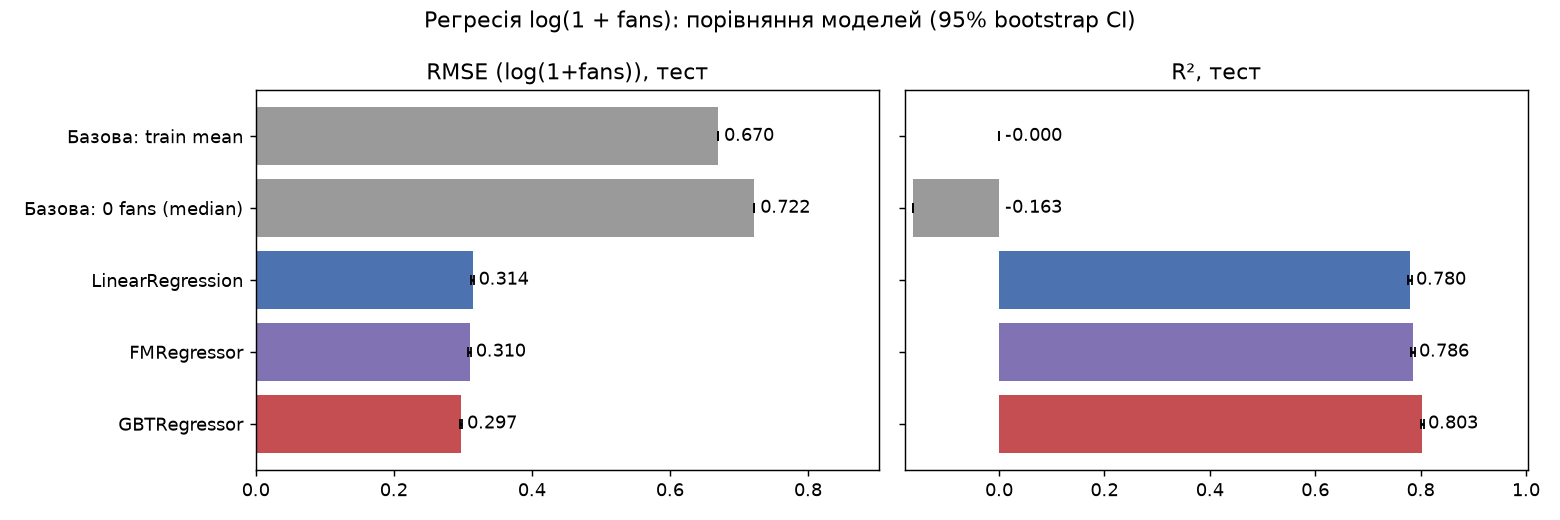

Paired bootstrap, top-2 models: {'a': 'GBTRegressor', 'b': 'FMRegressor', 'metric': 'rmse', 'diff': -0.012648280265255996, 'ci_low': -0.013729324860701157, 'ci_high': -0.011530205815560001, 'share_a_better': 1.0}


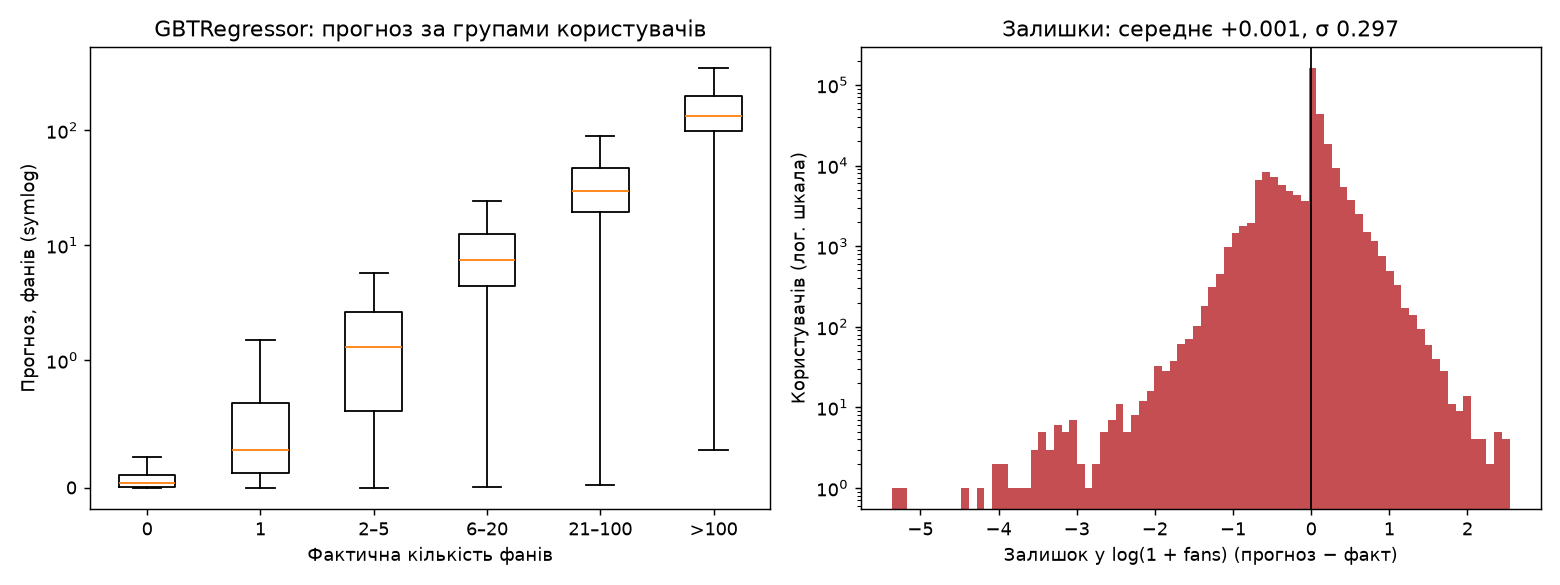

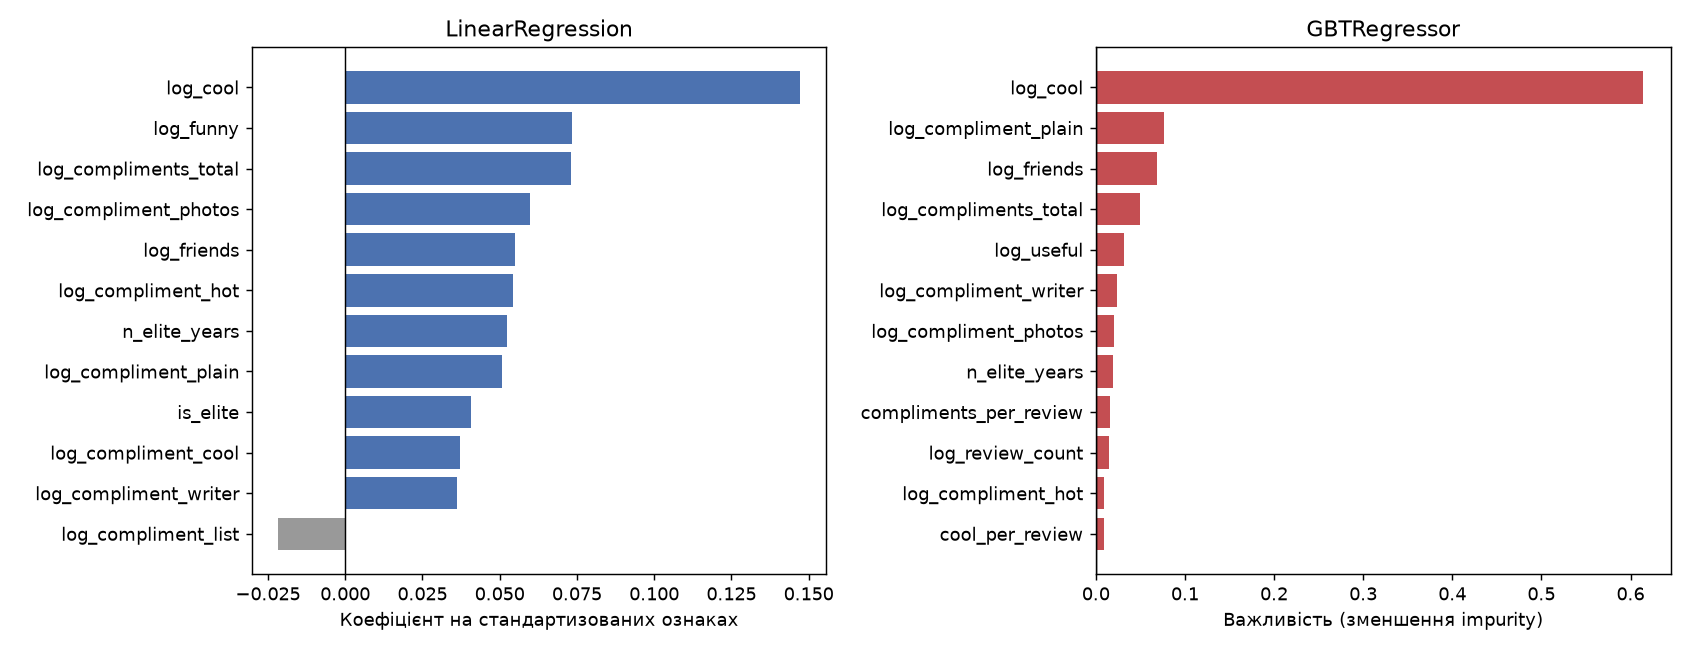

In [9]:
display(reg_tables["comparison"])
display(reg_tables["generalisation"])
show(plots.regression_comparison(regression, FIG / "reg_comparison.png"))
print("Paired bootstrap, top-2 models:", regression.extras["top_two"])
for path in [
    plots.regression_predictions(regression, FIG / "reg_predictions.png"),
    plots.feature_importance(regression, [LINEAR, GBT], FIG / "reg_feature_importance.png"),
]:
    show(path)
release(regression.data)

## 4. Класифікація: чи був користувач в Yelp Elite (`is_elite`)

Моделі різних типів: лінійна (`LogisticRegression`), ансамбль дерев (`RandomForestClassifier`, беггінг) і
нейронна мережа (`MultilayerPerceptronClassifier`). Позитивний клас — **еліт** (4,6%): Precision / Recall / F1
рахуються саме для нього. Дисбаланс враховано порогом: для кожної моделі поріг обирається на validation
(максимум F1) і без змін застосовується до тесту; метрики при порозі 0,5 теж наведено.
Критерій вибору гіперпараметрів — PR-AUC на validation (не залежить від порогу).

In [10]:
classification = run_classification(features)
cls_tables = report.write_task(classification, TABLES)
display(cls_tables["splits"])

[19:42:48] Task classification: preparing data


[19:42:56] Task classification: 23 features, train/val/test = 1391658/298044/298195


[19:42:56] Task classification: tuning LogisticRegression (3 settings)


[19:43:09]   LogisticRegression {'regParam': 0.001} fit 4.6s train pr_auc=0.8876 val pr_auc=0.8870


[19:43:20]   LogisticRegression {'regParam': 0.01} fit 2.9s train pr_auc=0.8725 val pr_auc=0.8713


...

[19:52:49]   learning curve 4.3% (59639 rows) done


[19:53:03]   learning curve 10.0% (138902 rows) done


[19:53:25]   learning curve 24.3% (337961 rows) done


[19:54:05]   learning curve 50.0% (696313 rows) done


,split,rows,mean_is_elite
0,train,1391658,0.045812
1,validation,298044,0.046231
2,test,298195,0.045822


### 4.1 Підбір гіперпараметрів

In [11]:
print("F1 in this table is at the default threshold 0.5; selection uses PR-AUC.")
display(cls_tables["tuning"])

F1 in this table is at the default threshold 0.5; selection uses PR-AUC.


,model,params,fit_seconds,search_seconds,train_pr_auc,val_pr_auc,train_f1@0.5,val_f1@0.5
0,LogisticRegression,"{""regParam"": 0.001}",4.59,4.59,0.887595,0.887044,0.803166,0.802387
1,LogisticRegression,"{""regParam"": 0.01}",2.90,2.90,0.872524,0.871281,0.773958,0.775925
2,LogisticRegression,"{""regParam"": 0.1}",2.19,2.19,0.842766,0.842434,0.694246,0.694706
3,RandomForestClassifier,"{""numTrees"": 20, ""maxDepth"": 8}",8.53,8.53,0.888896,0.885751,0.811534,0.807744
4,RandomForestClassifier,"{""numTrees"": 60, ""maxDepth"": 8}",30.03,30.03,0.891112,0.887328,0.813486,0.809195
5,RandomForestClassifier,"{""numTrees"": 60, ""maxDepth"": 14}",121.42,121.42,0.949275,0.907704,0.877295,0.828322
6,MultilayerPerceptronClassifier,"{""hidden"": [16]}",26.83,26.83,0.912694,0.912838,0.829248,0.831785
7,MultilayerPerceptronClassifier,"{""hidden"": [32, 16]}",61.46,61.46,0.914171,0.913754,0.830452,0.831963
8,MultilayerPerceptronClassifier,"{""hidden"": [64, 32]}",140.17,140.17,0.913578,0.912803,0.829819,0.830716


### 4.2 Аналіз процесу навчання

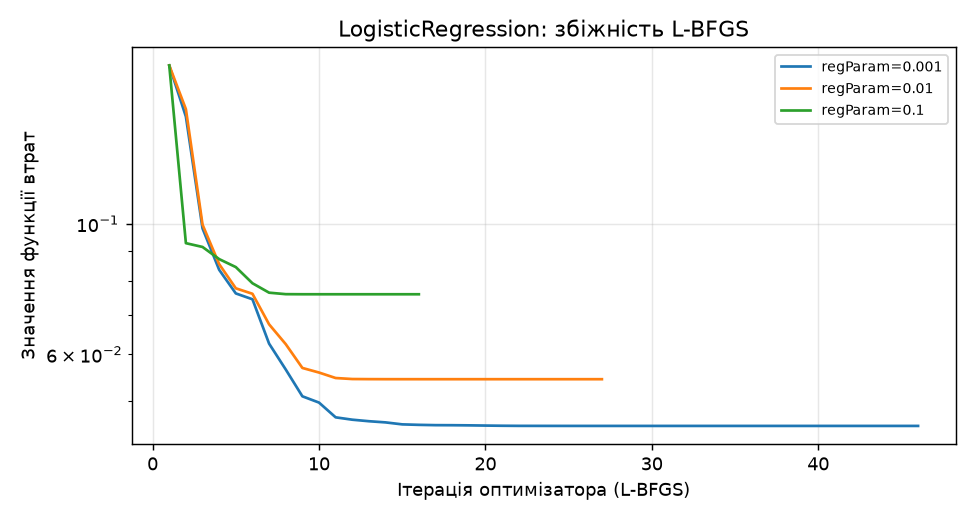

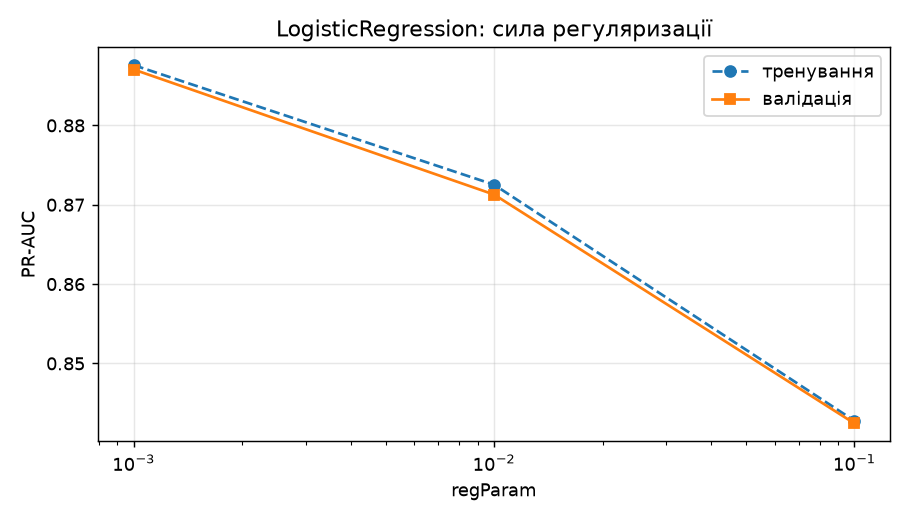

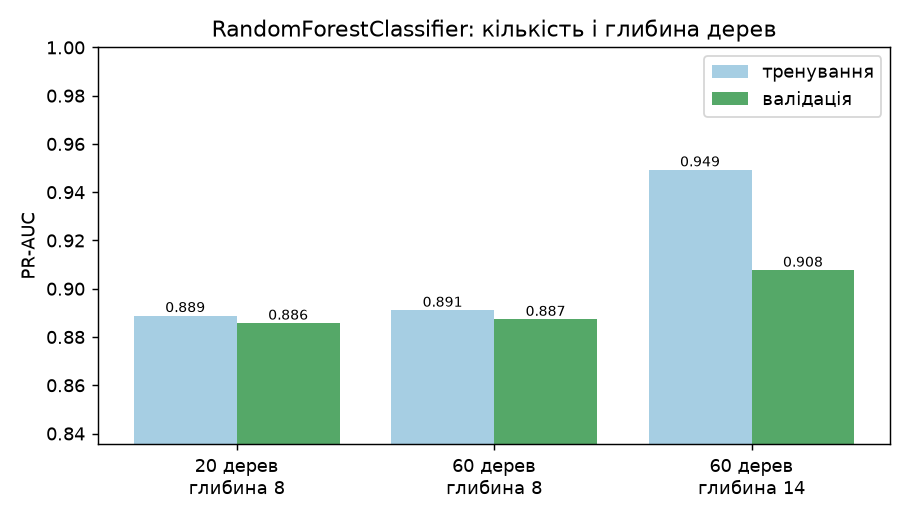

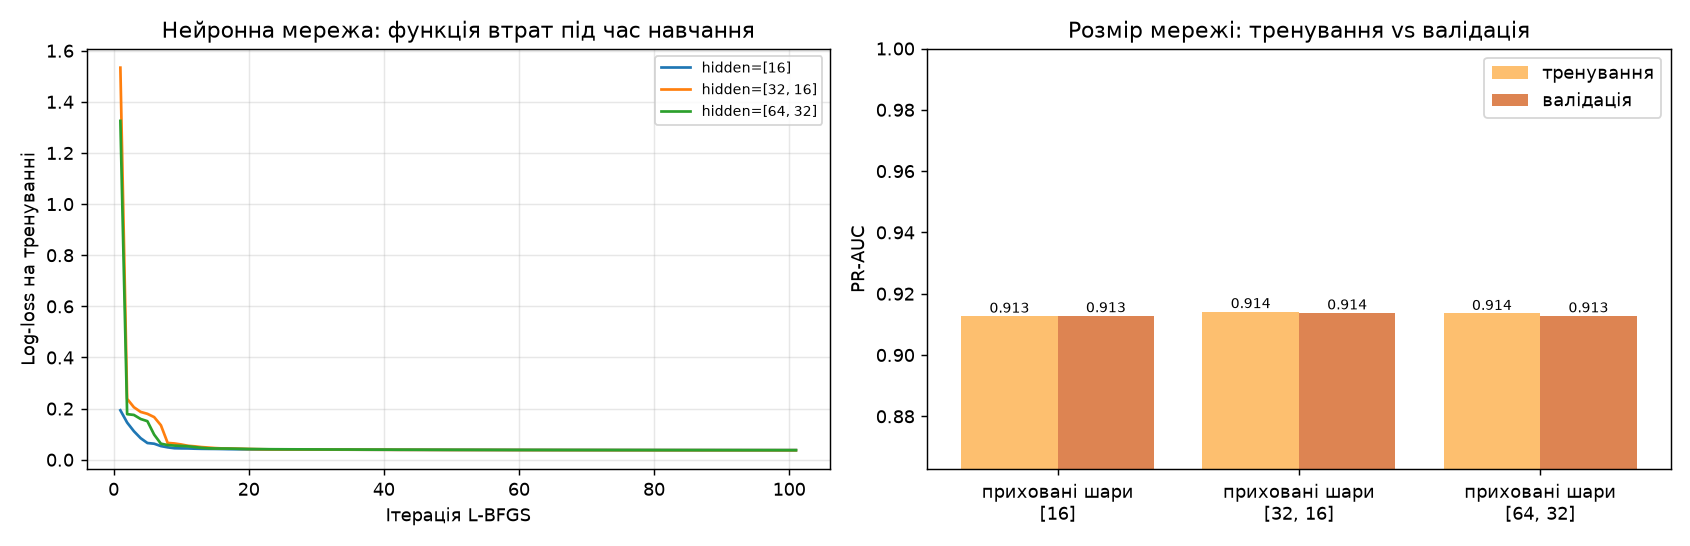

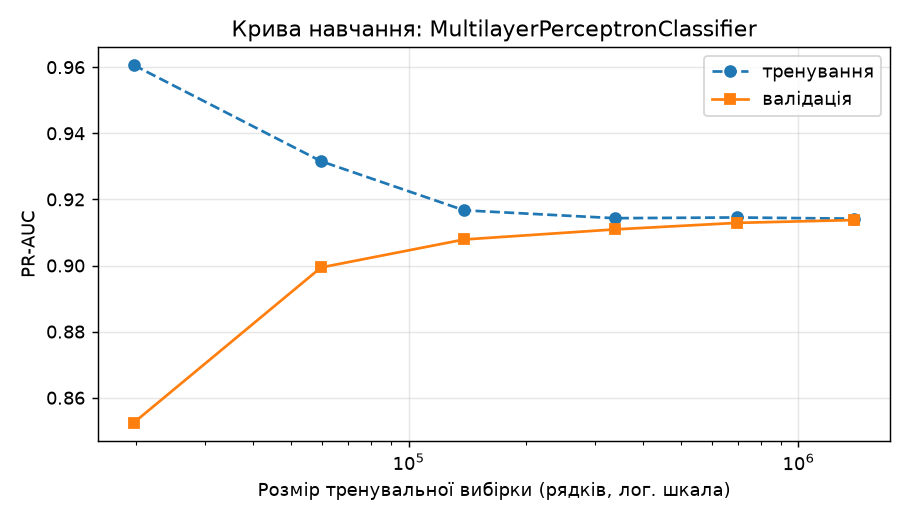

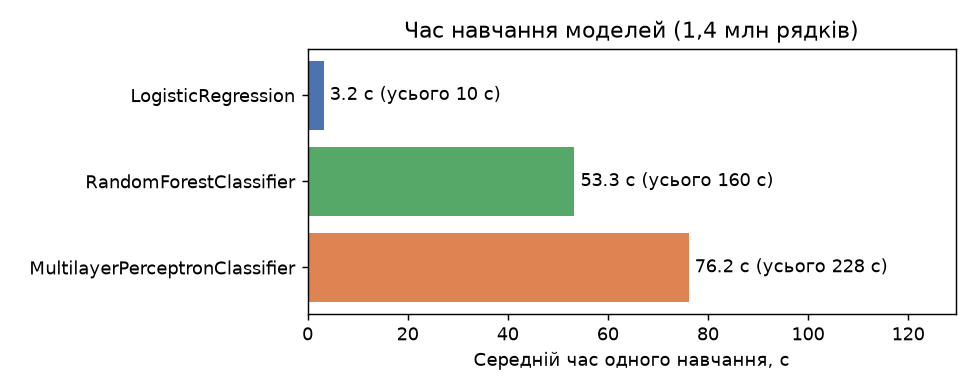

,train_fraction,train_rows,fit_seconds,train_accuracy,train_precision,train_recall,train_f1,train_macro_f1,train_weighted_f1,train_tp,train_fp,train_tn,train_fn,train_roc_auc,train_pr_auc,val_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_weighted_f1,val_tp,val_fp,val_tn,val_fn,val_roc_auc,val_pr_auc
0,0.014286,19732,4.27,0.990067,0.928571,0.851528,0.888383,0.941592,0.989862,780.0,60.0,18756.0,136.0,0.997546,0.960626,0.980879,0.826438,0.742289,0.782107,0.886054,0.980389,10228.0,2148.0,282117.0,3551.0,0.989629,0.852442
1,0.042857,59639,6.32,0.986049,0.873174,0.819034,0.845238,0.918967,0.985837,2272.0,330.0,56535.0,502.0,0.995729,0.931548,0.983918,0.855515,0.784672,0.818564,0.905075,0.983587,10812.0,1826.0,282439.0,2967.0,0.993860,0.899412
2,0.100000,138902,9.97,0.984917,0.858415,0.803237,0.829910,0.911009,0.984679,5111.0,843.0,131696.0,1252.0,0.994935,0.916693,0.984412,0.856563,0.796139,0.825246,0.908544,0.984140,10970.0,1837.0,282428.0,2809.0,0.994509,0.907876
3,0.242857,337961,18.26,0.984800,0.856906,0.801913,0.828498,0.910273,0.984560,12408.0,2072.0,320416.0,3065.0,0.994865,0.914319,0.984764,0.857397,0.804195,0.829944,0.910984,0.984532,11081.0,1843.0,282422.0,2698.0,0.994708,0.910925
4,0.500000,696313,34.05,0.984952,0.854904,0.809354,0.831505,0.911815,0.984756,25854.0,4388.0,659981.0,6090.0,0.994870,0.914532,0.984935,0.857407,0.808622,0.832300,0.912207,0.984725,11142.0,1853.0,282412.0,2637.0,0.994802,0.912902
5,1.000000,1391658,61.46,0.984864,0.852929,0.809129,0.830452,0.911265,0.984674,51586.0,8895.0,1319008.0,12169.0,0.994851,0.914171,0.984845,0.853457,0.811525,0.831963,0.912014,0.984663,11182.0,1920.0,282345.0,2597.0,0.994834,0.913754


In [12]:
for path in [
    plots.objective_history(classification, LOGISTIC, FIG / "cls_logistic_convergence.png",
                            "LogisticRegression: збіжність L-BFGS"),
    plots.param_curve(classification, LOGISTIC, "regParam", "pr_auc", FIG / "cls_logistic_regularization.png",
                      "LogisticRegression: сила регуляризації", "regParam", log_x=True),
    plots.forest_settings(classification, FIG / "cls_forest.png"),
    plots.mlp_training(classification, FIG / "cls_mlp_training.png"),
    plots.learning_curve(classification, "pr_auc", FIG / "cls_learning_curve.png"),
    plots.fit_times(classification, FIG / "cls_fit_times.png"),
]:
    show(path)
display(cls_tables["learning_curve"])

### 4.3 Якість моделей: Accuracy, Precision, Recall, F1 (клас «еліт», тест)

,model,accuracy,precision,recall,f1,threshold,f1_95ci,pr_auc,pr_auc_95ci,roc_auc,fit_seconds,best_params
0,Baseline: majority (nobody elite),0.954178,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Baseline: review_count >= 88,0.968222,0.632767,0.730386,0.678081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LogisticRegression,0.982984,0.812227,0.817696,0.814953,0.37,[0.810; 0.821],0.887598,[0.882; 0.893],0.993706,4.6,"{""regParam"": 0.001}"
3,RandomForestClassifier,0.984074,0.821215,0.834016,0.827566,0.42,[0.823; 0.832],0.906477,[0.902; 0.911],0.994421,121.4,"{""numTrees"": 60, ""maxDepth"": 14}"
4,MultilayerPerceptronClassifier,0.984517,0.826961,0.837310,0.832103,0.43,[0.828; 0.838],0.914050,[0.910; 0.918],0.994919,61.5,"{""hidden"": [32, 16]}"


At the default threshold 0.5:


,model,accuracy,precision,recall,f1
0,LogisticRegression,0.982984,0.854666,0.757465,0.803135
1,RandomForestClassifier,0.984192,0.849010,0.796692,0.822019
2,MultilayerPerceptronClassifier,0.984742,0.850754,0.808914,0.829307


,model,train_pr_auc,val_pr_auc,test_pr_auc,train_roc_auc,val_roc_auc,test_roc_auc
0,LogisticRegression,0.887595,0.887044,0.887598,0.993556,0.993386,0.993706
1,RandomForestClassifier,0.949275,0.907704,0.906477,0.997065,0.994408,0.994421
2,MultilayerPerceptronClassifier,0.914171,0.913754,0.914050,0.994851,0.994834,0.994919


Paired bootstrap, top-2 models: {'a': 'MultilayerPerceptronClassifier', 'b': 'RandomForestClassifier', 'metric': 'pr_auc', 'diff': 0.007572747131063706, 'ci_low': 0.005813861778107476, 'ci_high': 0.009193076455691021, 'share_a_better': 1.0}


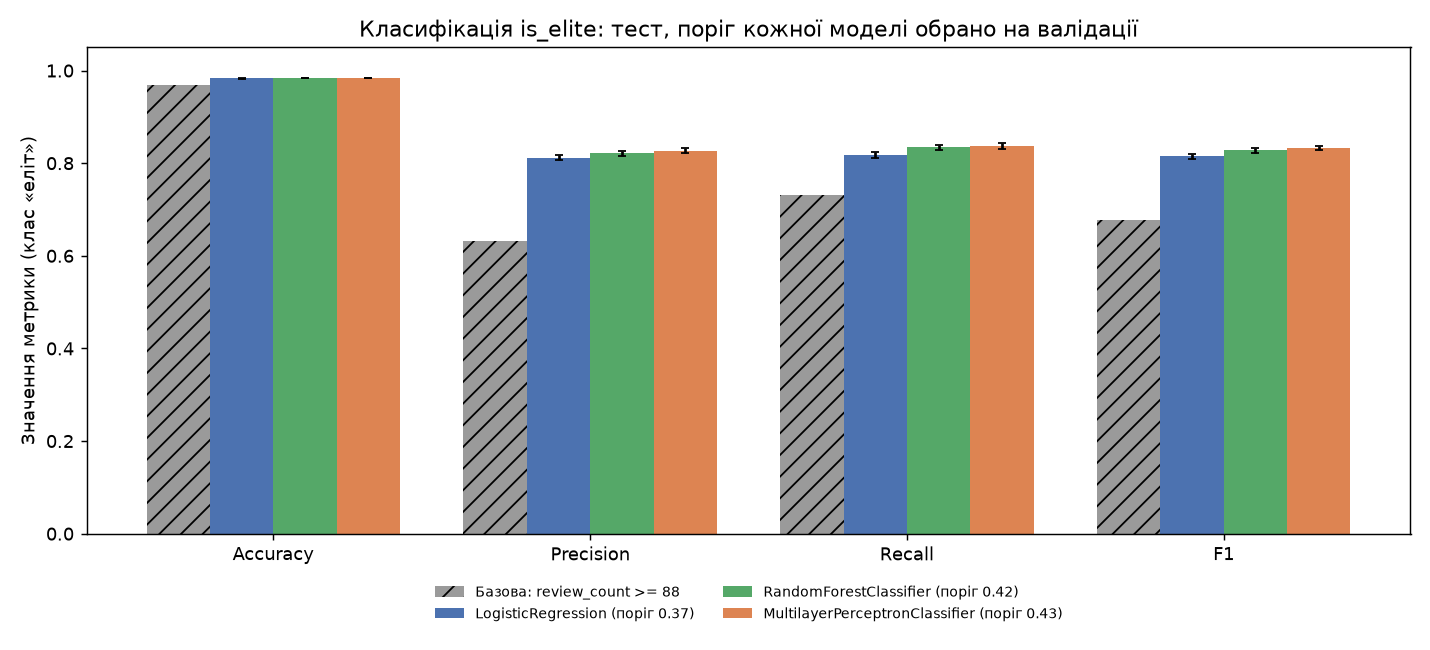

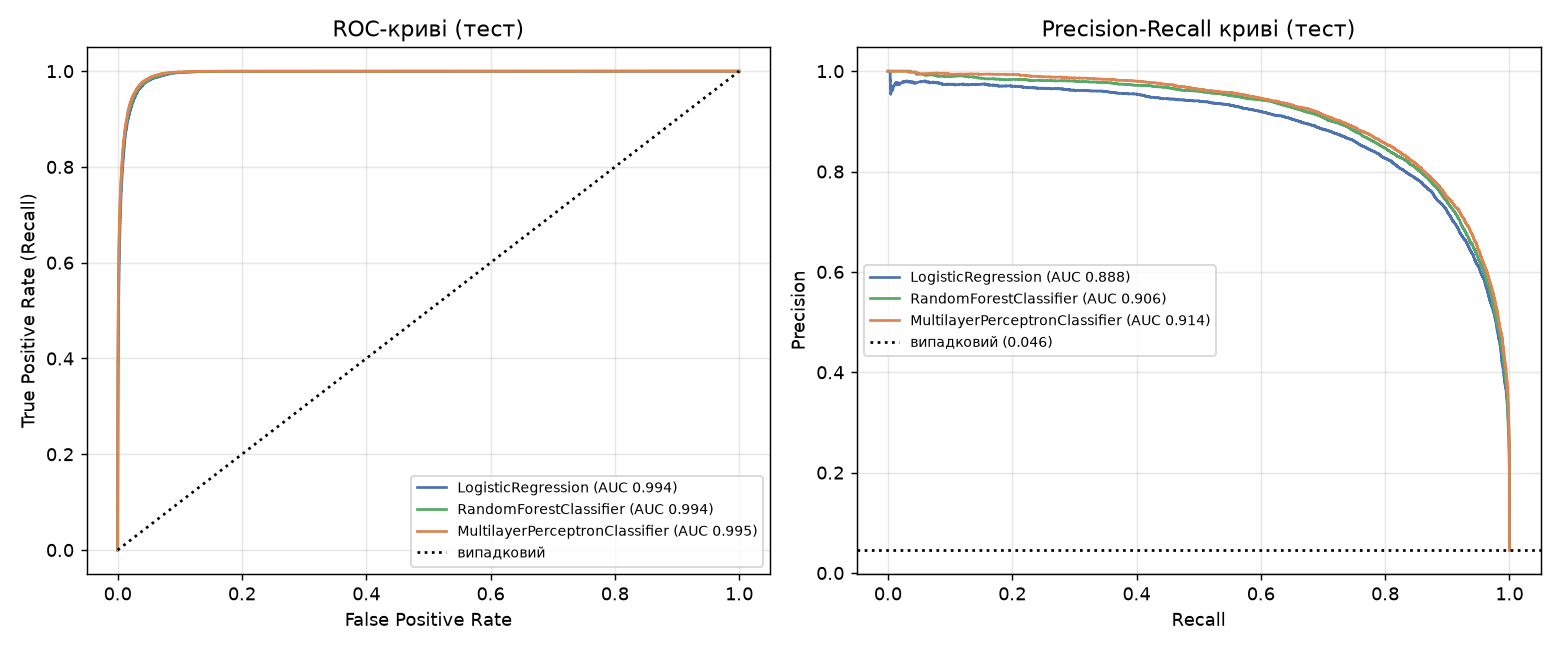

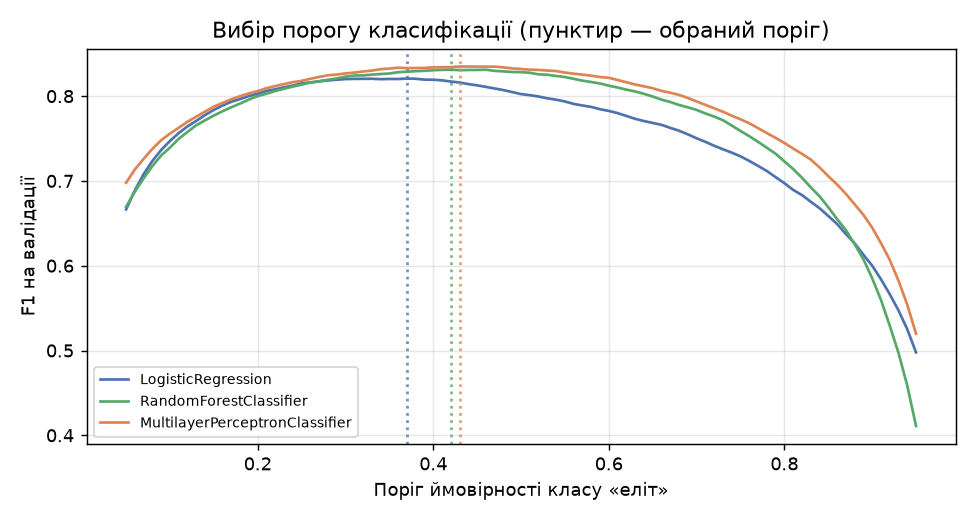

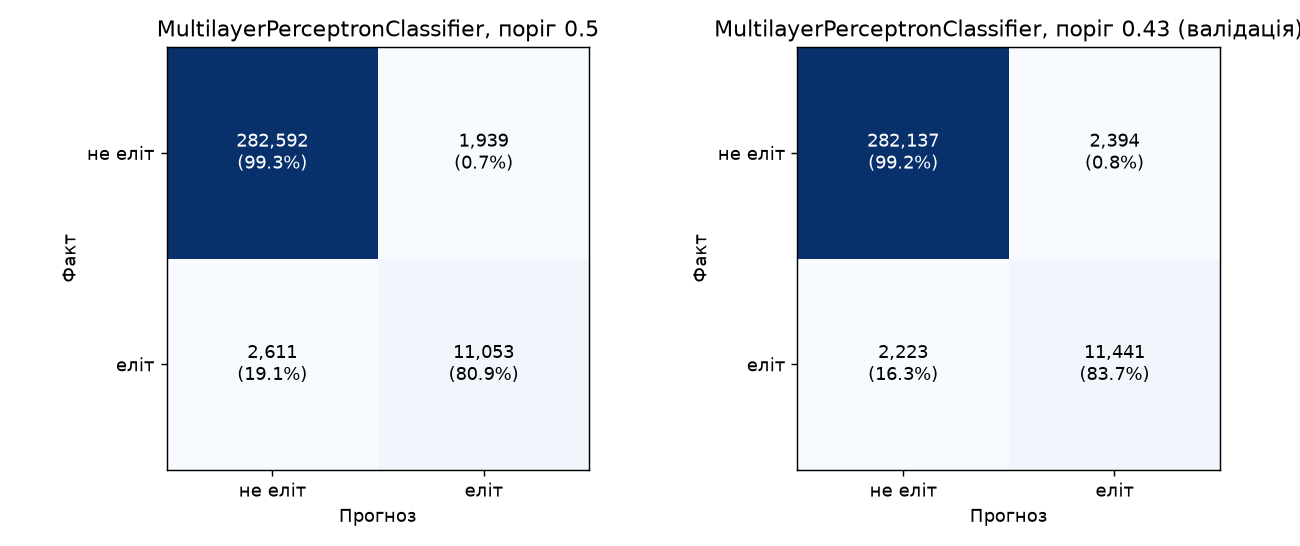

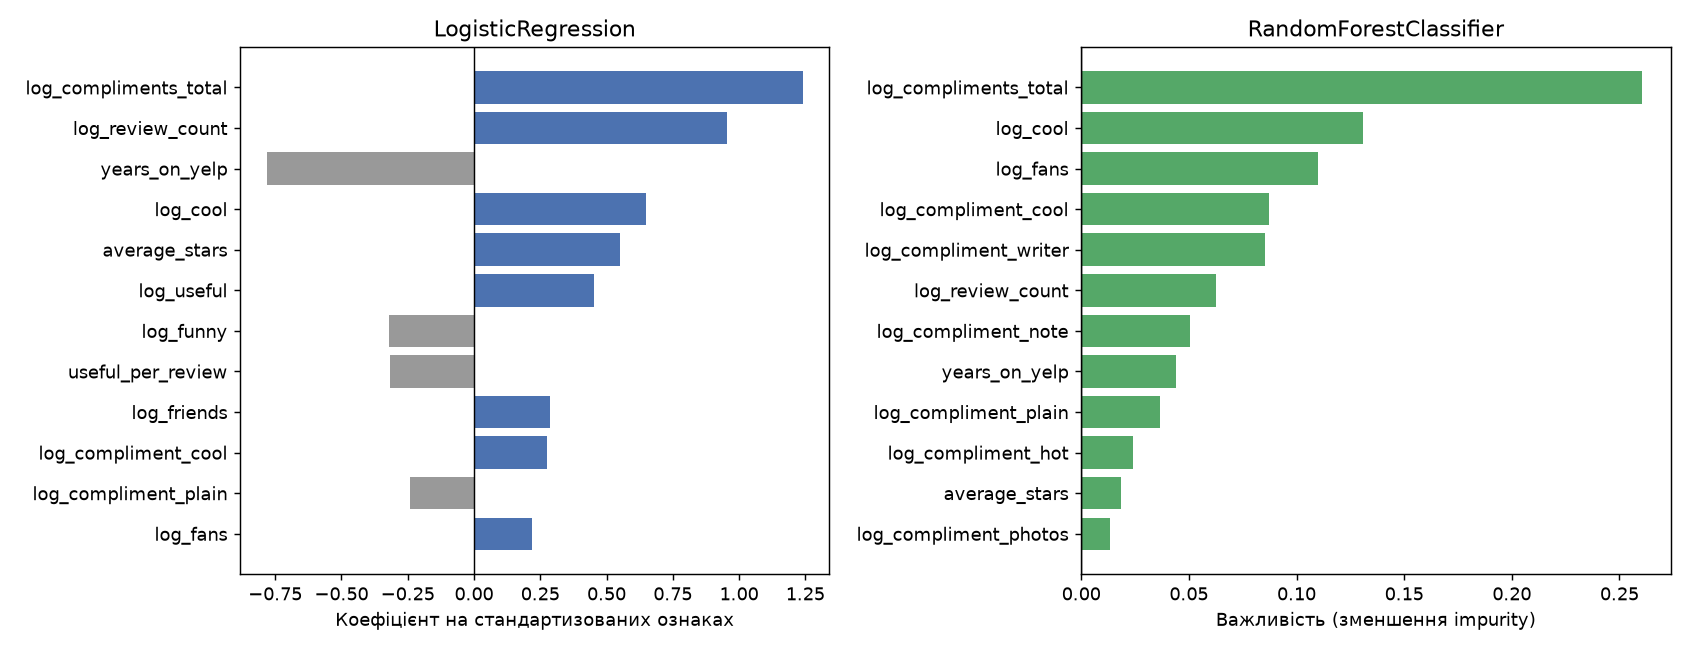

In [13]:
display(cls_tables["comparison"])
print("At the default threshold 0.5:")
display(cls_tables["threshold_0_5"])
display(cls_tables["generalisation"])
print("Paired bootstrap, top-2 models:", classification.extras["top_two"])
for path in [
    plots.classification_comparison(classification, FIG / "cls_comparison.png"),
    plots.roc_pr_curves(classification, FIG / "cls_roc_pr.png"),
    plots.threshold_curves(classification, FIG / "cls_threshold.png"),
    plots.confusion_matrices(classification, FIG / "cls_confusion.png"),
    plots.feature_importance(classification, [LOGISTIC, RANDOM_FOREST], FIG / "cls_feature_importance.png"),
]:
    show(path)
release(classification.data)

## 5. Порівняння алгоритмів

In [14]:
results = [regression, classification]
tables = {r.task.name: report.write_task(r, TABLES) for r in results}
stages = "\n".join(f"{i}. {s}" for i, s in enumerate(regression.data.preprocessing.stages, 1))
report.write_digest(results, tables, ML_REPORT_DIR / "results.md", stages)

summary = report.summary(results)
summary["runtime_minutes"] = (time.perf_counter() - started) / 60
ML_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(ML_RESULTS_DIR / "summary.json").write_text(json.dumps(summary, indent=2, default=str), encoding="utf-8")

overview = []
for m in regression.models:
    overview.append({"task": "regression", "model": m.spec.name,
                     "RMSE": m.test_metrics["rmse"], "R2": m.test_metrics["r2"],
                     "fit_s": round(m.fit_seconds, 1), "selected": m is regression.best})
for m in classification.models:
    t = m.test_tuned
    overview.append({"task": "classification", "model": m.spec.name,
                     "Accuracy": t["accuracy"], "Precision": t["precision"], "Recall": t["recall"],
                     "F1": t["f1"], "PR-AUC": t["pr_auc"], "fit_s": round(m.fit_seconds, 1),
                     "selected": m is classification.best})
display(pd.DataFrame(overview))
print(f"Total runtime: {summary['runtime_minutes']:.1f} min")

,task,model,RMSE,R2,fit_s,selected,Accuracy,Precision,Recall,F1,PR-AUC
0,regression,LinearRegression,0.314182,0.779866,5.4,False,NaN,NaN,NaN,NaN,NaN
1,regression,FMRegressor,0.310064,0.785600,166.9,False,NaN,NaN,NaN,NaN,NaN
2,regression,GBTRegressor,0.297415,0.802735,73.5,True,NaN,NaN,NaN,NaN,NaN
3,classification,LogisticRegression,NaN,NaN,4.6,False,0.982984,0.812227,0.817696,0.814953,0.887598
4,classification,RandomForestClassifier,NaN,NaN,121.4,False,0.984074,0.821215,0.834016,0.827566,0.906477
5,classification,MultilayerPerceptronClassifier,NaN,NaN,61.5,True,0.984517,0.826961,0.837310,0.832103,0.914050


Total runtime: 27.2 min


## Висновки

* **Регресія `log(1 + fans)`:** найкращий `GBTRegressor` — RMSE 0,297, R² 0,803 (база «середнє»: RMSE 0,670, R² 0);
  `FMRegressor` — 0,310 / 0,786, `LinearRegression` — 0,314 / 0,780. FM найчутливіший до кроку навчання:
  при 0,1 оптимізатор розбігається.
* **Класифікація `is_elite`** (поріг кожної моделі обрано на validation): найкраща нейронна мережа —
  Accuracy 0,985, Precision 0,827, Recall 0,837, F1 0,832, PR-AUC 0,914; RandomForest — F1 0,828 (глибокі дерева
  перенавчаються); LogisticRegression — F1 0,815, але в 13–25 разів швидша. Правило «≥ 88 відгуків» дає лише F1 0,678,
  а модель «ніхто не еліт» — Accuracy 0,954 при F1 = 0.
* Різниці між моделями невеликі, але статистично значущі (парний bootstrap). Більше даних після ~0,3–0,7 млн рядків
  майже не допомагає: якість обмежена ознаками.

Детальний аналіз і обмеження — у [`src/reports/ml/README.md`](../reports/ml/README.md).

In [15]:
spark.stop()